# `**DISSERTATION CODE **`

# **Understanding the Dataset through Distributions**

In [1]:
#Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import shap
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.colors as mcolors
import os
import sys
import folium
from folium.plugins import HeatMap, MarkerCluster
import branca.colormap as cm

In [2]:
# Importing the dataset

dataset = pd.read_csv("Data.csv")

In [3]:
# Preprocessing and encoding of data

from sklearn.preprocessing import LabelEncoder

Categorical = dataset.select_dtypes(include=["object"]).columns.tolist()
Label_Encoder = {}

In [4]:
for diff_cols in Categorical:                          # Changes all the categorical (non-numeric) values to numeric, for easy interpretation
    le = LabelEncoder()
    dataset[diff_cols] = le.fit_transform(dataset[diff_cols].astype(str))
    Label_Encoder[diff_cols] = le

# Finding how old/new the project is, as it may have an effect on the output

dataset["Project_Age"] = 2025 - dataset["Year Operational"]
dataset

,Project Name,Project Type,City,County,State,Digester Type,Status,Year Operational,Dairy,Poultry,...,Awarded USDA Funding?,Operational Years,Total_Animals,Biogas_per_Animal (cu-ft/day),Emission_Reduction_per_Year,Electricity_to_Biogas_Ratio,Total_Waste_kg/day,Waste_Efficiency,Electricity_Efficiency,Project_Age
0,74,1,197,31,1,3,1,2008,0,0,...,0,15,4200,432.000000,298.850354,0.000000,21000,86.400000,0.000000,17
1,69,1,33,107,0,7,1,2022,11760,0,...,1,1,11760,9.310034,14030.128980,3.559343,399840,0.273825,0.974635,3
2,72,1,93,140,0,12,0,2022,8800,0,...,0,1,8800,10.738636,98999.890160,29.768047,299200,0.315842,9.402007,3
3,173,0,180,140,0,1,1,2018,30000,0,...,0,5,30000,115.150000,67499.925110,0.799055,1020000,3.386765,2.706212,7
4,313,1,115,107,0,1,1,2021,10000,0,...,0,2,10000,85.254520,50284.746700,0.000000,340000,2.507486,0.000000,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,331,1,304,194,34,7,2,2005,1200,0,...,1,18,1200,296.683333,2519.246478,9.411550,40800,8.725980,82.125000,20
487,401,1,77,15,34,5,2,2002,1000,0,...,0,21,1000,310.865600,2399.577244,3.043373,34000,9.143106,27.825882,23
488,420,1,312,74,34,4,2,1999,1800,0,...,0,24,1800,111.111111,1923.477295,27.922500,61200,3.267974,91.250000,26
489,430,1,46,191,34,1,2,2011,200,0,...,0,12,200,115.000000,7622.068718,139.398261,6800,3.382353,471.494118,14


In [5]:
# Checking if there are any missing values in the dataset

print(dataset.isnull().sum())

Project Name                              0
Project Type                              0
City                                      0
County                                    0
State                                     0
Digester Type                             0
Status                                    0
Year Operational                          0
Dairy                                     0
Poultry                                   0
Swine                                     0
Co-Digestion                              0
Biogas Generation Estimate (cu-ft/day)    0
Electricity Generated (kWh/yr)            0
Biogas End Use(s)                         0
LCFS Pathway?                             0
Receiving Utility                         0
Total Emission Reductions (MTCO2e/yr)     0
Awarded USDA Funding?                     0
Operational Years                         0
Total_Animals                             0
Biogas_per_Animal (cu-ft/day)             0
Emission_Reduction_per_Year     

In [6]:
# Figuring out the frequency of each livestock type

Livestock_Types = ["Dairy", "Poultry", "Swine"]

Counts = {}
for types in Livestock_Types:
    if types in dataset.columns:
        Counts[types] = (dataset[types] > 0).sum()

Count_Series = pd.Series(Counts)

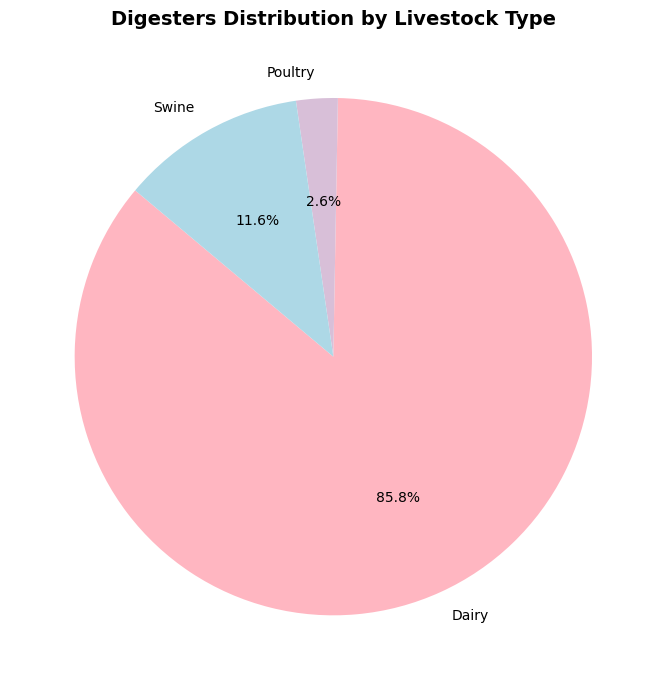

In [7]:
Pastels = ["#FFB6C1", "#D8BFD8", "#ADD8E6", "#B0E0E6"]

plt.figure(figsize=(7,7))
plt.pie(
    Count_Series,
    labels=Count_Series.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=Pastels
)

plt.title("Digesters Distribution by Livestock Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

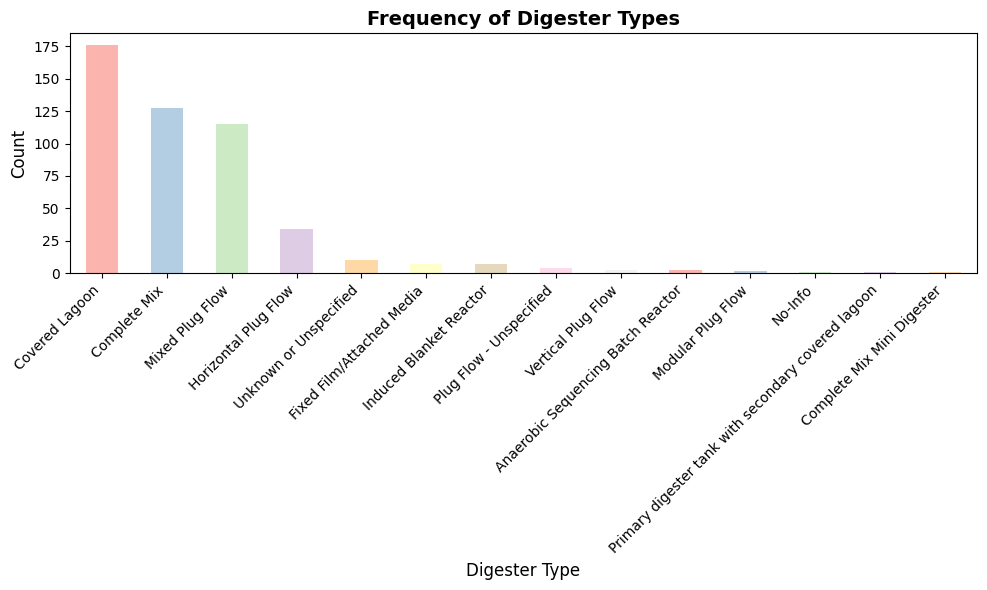

In [8]:
#Figuring out the distribution of digesters

dataset = pd.read_csv("Data.csv")

digester_freq = dataset["Digester Type"].value_counts()

plt.figure(figsize=(10,6))

digester_freq.plot(kind="bar", color=plt.cm.Pastel1.colors)

plt.title("Frequency of Digester Types", fontsize=14, fontweight="bold")
plt.xlabel("Digester Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [9]:
Livestock = ["Swine", "Dairy", "Poultry"]
Comparisons =[]

for animals in Livestock:

  if animals in dataset.columns:
    animals_data = dataset[dataset[animals] > 0].copy()
  else:
    continue

#Measuring efficiency across various livestock types

  for efficiency in ["Electricity_Efficiency", "Waste_Efficiency"]:
    if efficiency in animals_data.columns:
      Livestock_Efficiency = animals_data[efficiency].astype(int)


    Comparisons.append({
    "animal": animals,
    "metric": efficiency,
    "count": len(Livestock_Efficiency),
    "mean": Livestock_Efficiency.mean(),
    "median": Livestock_Efficiency.median(),
    "p25": Livestock_Efficiency.quantile(0.25),
    "p75": Livestock_Efficiency.quantile(0.75)
    })

# Turn results into a nice table
comparison_df = pd.DataFrame(Comparisons)
display(comparison_df)

,animal,metric,count,mean,median,p25,p75
0,Swine,Electricity_Efficiency,58,40.051724,11.5,1.25,27.00
1,Swine,Waste_Efficiency,58,351.120690,5.0,0.00,17.75
2,Dairy,Electricity_Efficiency,430,41.076744,18.0,0.00,46.75
3,Dairy,Waste_Efficiency,430,10.546512,2.0,1.00,8.00
4,Poultry,Electricity_Efficiency,13,87.769231,64.0,22.00,115.00
5,Poultry,Waste_Efficiency,13,24.461538,14.0,6.00,37.00


# **Biogas/Electricity Generation**

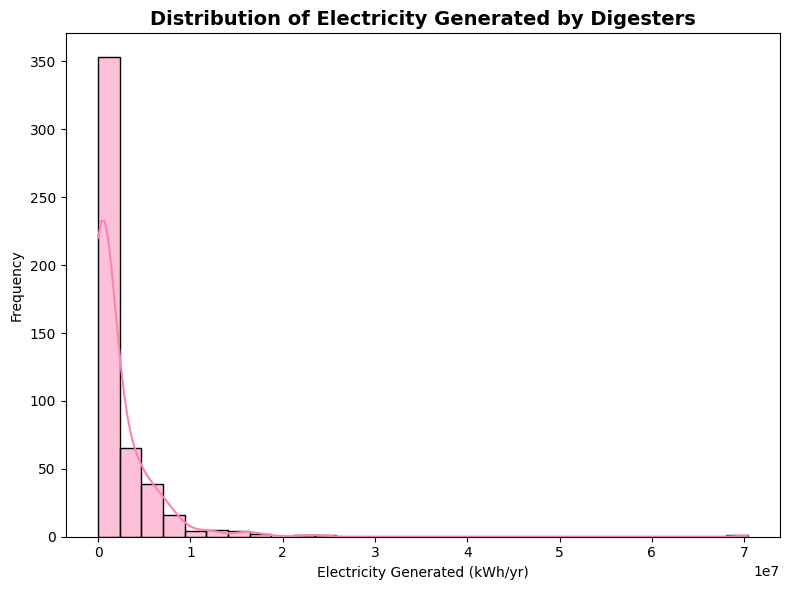

In [10]:
# Distribution of electricity generated by digesters

plt.figure(figsize=(8,6))

sns.histplot(dataset["Electricity Generated (kWh/yr)"], bins=30, kde=True, color="#fb83b3")


plt.title("Distribution of Electricity Generated by Digesters", fontsize=14, fontweight="bold")
plt.xlabel("Electricity Generated (kWh/yr)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

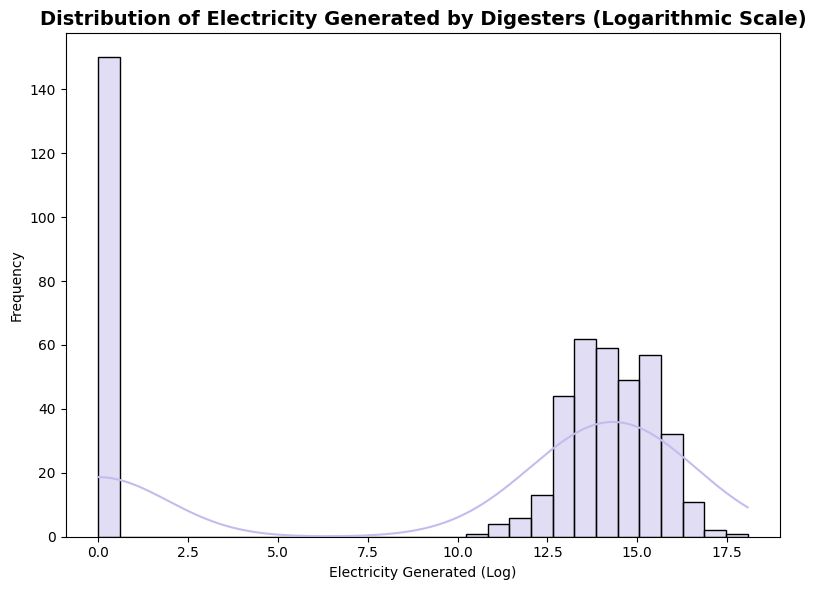

In [11]:
# Since the above chart (Histogram), is highly skewed. We try to make a histogram for the same variables but with a logarithmic scale.

# Apply log transform (log1p = log(1+x), safe for zero values)
dataset["log_electricity"] = np.log1p(dataset["Electricity Generated (kWh/yr)"])  #Log transformation

# Histogram on log scale
plt.figure(figsize=(8,6))
sns.histplot(dataset["log_electricity"], bins=30, kde=True, color="#c4bced")



plt.title("Distribution of Electricity Generated by Digesters (Logarithmic Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Electricity Generated (Log)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [12]:
Average_Electricity_Generated = dataset["Electricity Generated (kWh/yr)"].mean()
print("***Average Electricity Generated:", Average_Electricity_Generated, "***")

***Average Electricity Generated: 2218724.1629327904 ***


In [13]:
#To understand the working of digesters based on regions, US states have been divided into "5" regions and the analysis will take place according to it.
Loca_dataset = pd.read_csv("Location.csv")  #Have managed to add Latitude & Longitude in the dataset and have named it "Location". This new dataset is the same as the one being used already just 2 variables have been added.

Region_Names = {
    "Northeast": ["Maine", "New Hampshire", "Vermont", "Massachusetts", "Rhode Island", "Connecticut", "New York", "New Jersey", "Pennsylvania"],
    "Southeast": ["Delaware", "Maryland", "District of Columbia", "Virginia", "West Virginia", "Kentucky", "North Carolina", "South Carolina", "Tennessee", "Georgia", "Florida", "Alabama", "Mississippi", "Arkansas", "Louisiana"],
    "Midwest": ["Ohio", "Michigan", "Indiana", "Illinois", "Wisconsin", "Minnesota", "Iowa", "Missouri", "North Dakota", "South Dakota", "Nebraska", "Kansas"],
    "Southwest": ["Texas", "Oklahoma", "New Mexico", "Arizona"],
    "West": ["Colorado", "Wyoming", "Montana", "Idaho", "Utah", "Nevada"," California", "Oregon", "Washington", "Alaska", "Hawaii"]
}

Different_States = {}

for region, states in Region_Names.items():
  for state in states:
    Different_States[state] = region


Loca_dataset["States"] = (Loca_dataset["State"].astype(str).str.strip())


Loca_dataset["Regions"] = Loca_dataset["States"].map(Different_States)

/tmp/ipython-input-2655567248.py:11: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.stripplot(


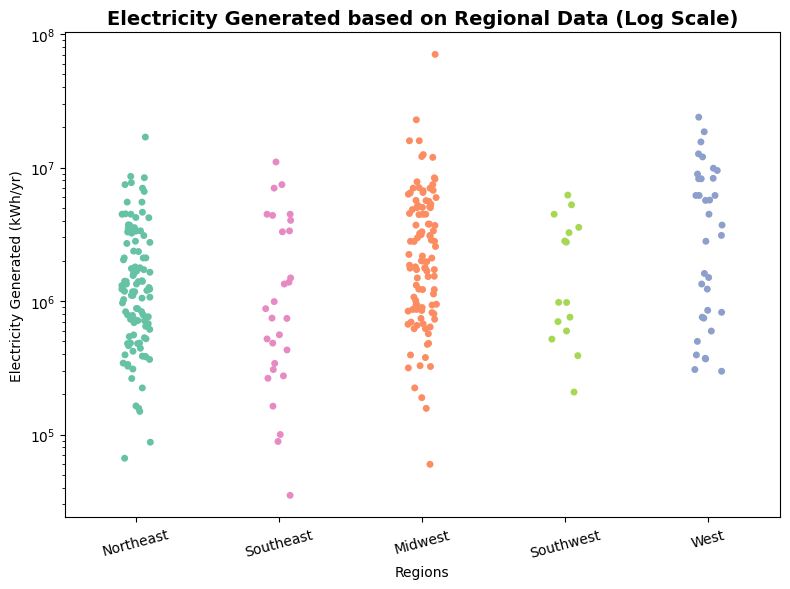

In [14]:
Sequence = ["Northeast", "Southeast", "Midwest", "Southwest", "West"]
Sy_Sequence = Sequence + (["Other"] if "Other" in Loca_dataset["Regions"].unique() else [])

CO2EM_Columns= "Electricity Generated (kWh/yr)"

Mapping_CO2EM = Loca_dataset[(Loca_dataset[CO2EM_Columns] > 0) & Loca_dataset["Regions"].notna()]

palette = sns.color_palette("Set2")

plt.figure(figsize=(8,6))
sns.stripplot(
    data= Mapping_CO2EM, x="Regions", y=CO2EM_Columns, order= Sy_Sequence, hue="Regions", palette=palette)
plt.yscale("log")

plt.xlabel("Regions")
plt.title("Electricity Generated based on Regional Data (Log Scale)", fontsize=14, fontweight="bold")
plt.ylabel("Electricity Generated (kWh/yr)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2291689660.py:7: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.stripplot(data=Mapping_Emissions, x="Regions", y=Emission_Column, order=Sy_Sequence, hue="Regions", palette=palette)


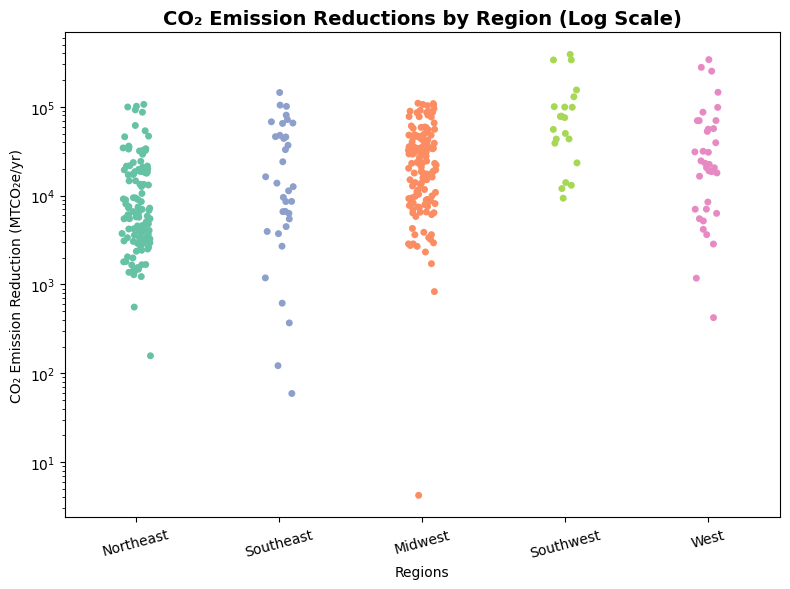

In [15]:

Emission_Column = "Total Emission Reductions (MTCO2e/yr)"


Mapping_Emissions = Loca_dataset[(Loca_dataset[Emission_Column].notna()) &(Loca_dataset[Emission_Column] > 0) & (Loca_dataset["Regions"].notna())]

plt.figure(figsize=(8,6))
sns.stripplot(data=Mapping_Emissions, x="Regions", y=Emission_Column, order=Sy_Sequence, hue="Regions", palette=palette)

plt.yscale("log")
plt.xlabel("Regions")

plt.title("CO₂ Emission Reductions by Region (Log Scale)", fontsize=14, fontweight="bold")
plt.ylabel("CO₂ Emission Reduction (MTCO₂e/yr)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# **CO2 Emission Reduction**

In [16]:
# Figuring out distribution w.r.t. CO2 Emission Reduction

rows = []
for animals in Livestock_Types:
    if animals in dataset.columns:
        temp = dataset.loc[dataset[animals] > 0, ["Emission_Reduction_per_Year"]].copy()
        temp["Livestock"] = animals

        temp["Count"] = dataset.loc[dataset[animals] > 0, animals].values
        rows.append(temp)

/tmp/ipython-input-534073915.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Livestock", y="Emission_Reduction_per_Year", data=Combination, palette="rocket")


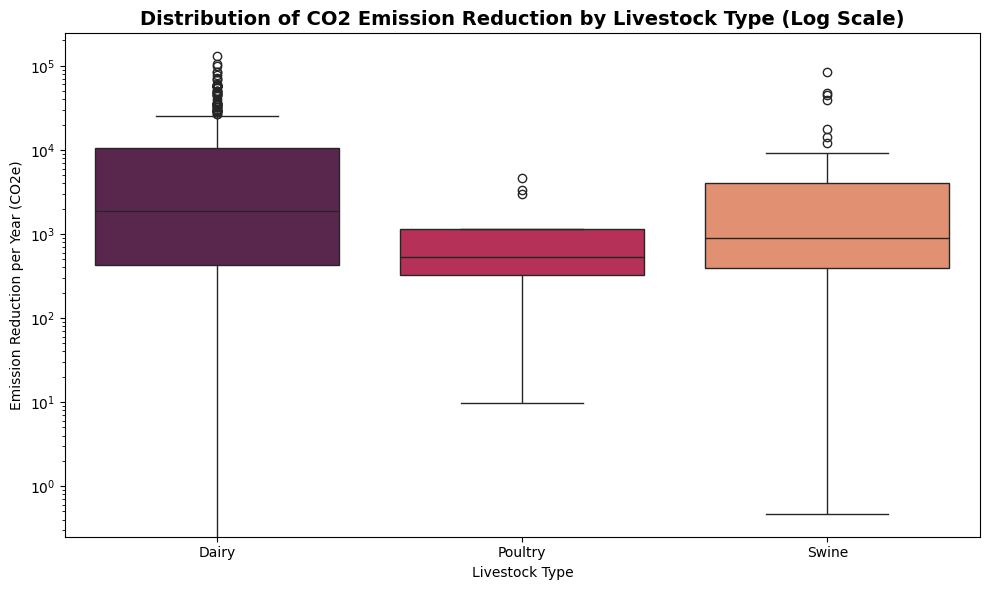

In [17]:
Combination = pd.concat(rows, ignore_index=True)

#Plotting a box plot

plt.figure(figsize=(10,6))
sns.boxplot(x="Livestock", y="Emission_Reduction_per_Year", data=Combination, palette="rocket")
plt.yscale("log")

plt.title("Distribution of CO2 Emission Reduction by Livestock Type (Log Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Livestock Type")
plt.ylabel("Emission Reduction per Year (CO2e)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3267301294.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=Var2, y=Variable, data=Box_Plot, palette="husl")


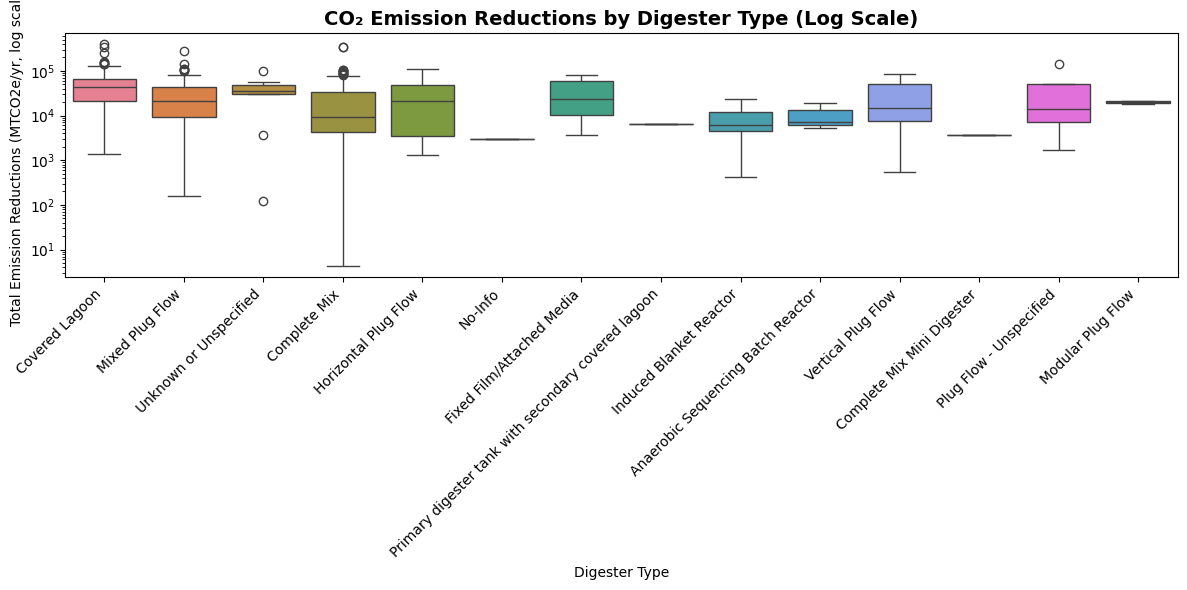

In [18]:
Variable = "Total Emission Reductions (MTCO2e/yr)"
Var2 = "Digester Type"


Box_Plot = dataset[[Var2, Variable]]

plt.figure(figsize=(12,6))
sns.boxplot(x=Var2, y=Variable, data=Box_Plot, palette="husl")

plt.yscale("log")

plt.title("CO₂ Emission Reductions by Digester Type (Log Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Digester Type")
plt.ylabel("Total Emission Reductions (MTCO2e/yr, log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3783472674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x= "Operational Years", y="Total Emission Reductions (MTCO2e/yr)", palette="magma")


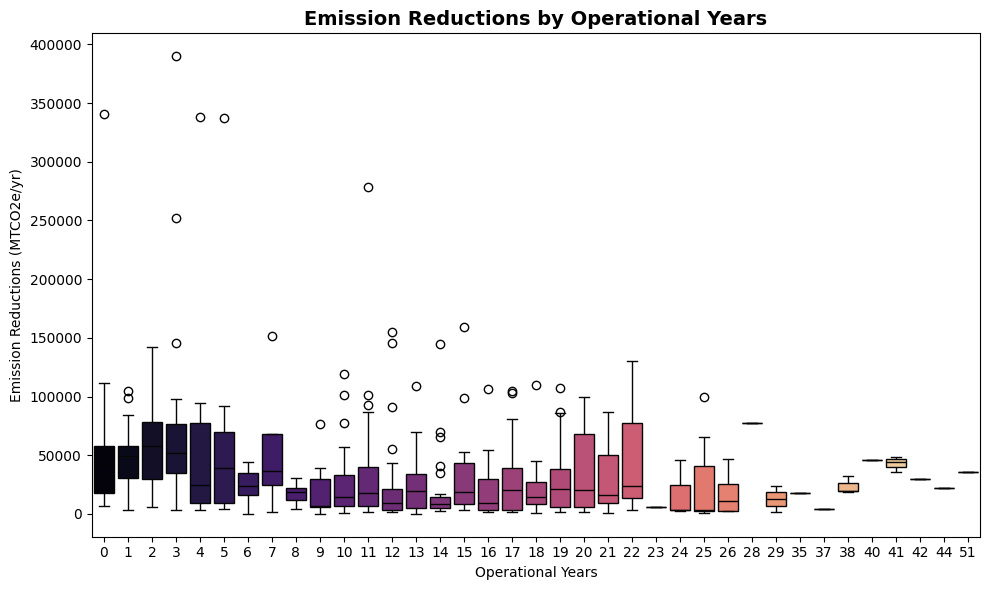

In [19]:
# Plotting another box plot w.r.t operational years

plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x= "Operational Years", y="Total Emission Reductions (MTCO2e/yr)", palette="magma")

plt.xlabel("Operational Years")
plt.ylabel("Emission Reductions (MTCO2e/yr)")

plt.title("Emission Reductions by Operational Years", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [20]:
Predict = "Total Emission Reductions (MTCO2e/yr)"

#Dropping unnecessary features

New_Dataset = ["Project Name", "City", "County", "State", "Biogas End Use(s)", "Receving Utility"]

X = dataset.drop(columns=[Cols for Cols in New_Dataset if Cols in dataset.columns] + [Predict], errors="ignore")   # "Emission Reduction" stored in "Y" and all the other features are stored in "X".
Y = dataset[Predict]

In [21]:
#Encoding

for new_cols in X.select_dtypes(include=["object"]).columns.tolist():
    le = LabelEncoder()
    X[new_cols] = le.fit_transform(X[new_cols].astype(str))

In [22]:
#K-Fold
from sklearn.model_selection import KFold

KF = KFold(n_splits=5, shuffle=True, random_state=42)

MAE_Scores = []
R2_Scores = []

In [23]:
for fold, (train_index, test_index) in enumerate(KF.split(X), start= 1):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  Y_train, Y_test = Y[train_index], Y[test_index]


  Model1 = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)

  Model1.fit(X_train, Y_train)
  Y_pred = Model1.predict(X_test)

  R2_Scores.append(r2_score(Y_test, Y_pred))
  MAE_Scores.append(mean_absolute_error(Y_test, Y_pred))
  print(f"Fold{fold}:R2={R2_Scores[-1]:.3f}, MAE={MAE_Scores[-1]:.3f}")

print()

print(f"Cross Validation R2 Score: {np.mean(R2_Scores):.3f} ± {np.std(R2_Scores):.3f}")
print(f"Cross Validation MAE Score: {np.mean(MAE_Scores):.3f} ± {np.std(MAE_Scores):.3f}")

Fold1:R2=0.914, MAE=4945.546
Fold2:R2=0.186, MAE=11472.581
Fold3:R2=0.809, MAE=9606.132
Fold4:R2=0.579, MAE=9004.243
Fold5:R2=0.248, MAE=7580.279

Cross Validation R2 Score: 0.547 ± 0.291
Cross Validation MAE Score: 8521.756 ± 2181.362


In [24]:
# Model Training

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

XGmodel = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
XGmodel.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [25]:
# Final Prediction
Y_pred_final = XGmodel.predict(X_test)

Outcome_r2 = r2_score(Y_test, Y_pred_final)
Outcome_mae = mean_absolute_error(Y_test, Y_pred_final)

print("\nFinal Evaluations:")
print(f"R2:  {Outcome_r2:.3f}")
print(f"MAE: {Outcome_mae:.3f}")


Final Evaluations:
R2:  0.914
MAE: 4945.546


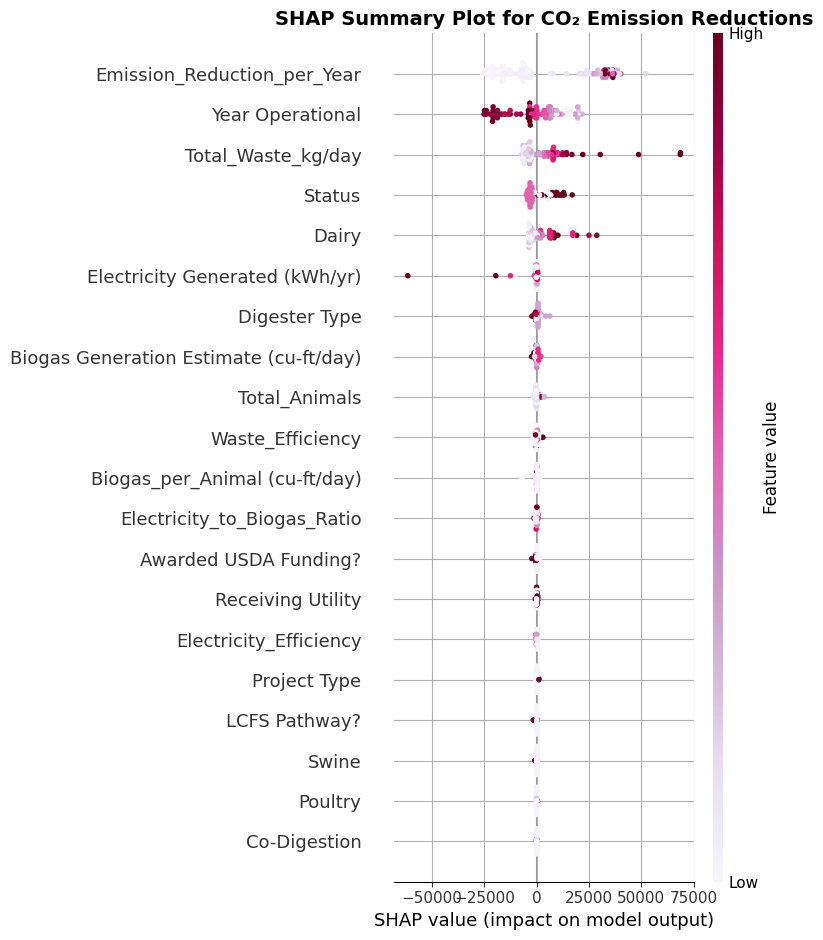

In [26]:
#Plotting SHAP Plot

                                                                        # Depicts how much each feature contributed to the model's predictions
Explainer = shap.Explainer(XGmodel, X_train)
Shap_Values = Explainer(X_test)

cmap = plt.cm.PuRd
Colors = [cmap(i) for i in range(cmap.N)]

plt.figure(figsize=(10,6))
shap.summary_plot(Shap_Values, X_test, plot_type="dot", cmap="PuRd", show=False)

plt.grid(True)

plt.title("SHAP Summary Plot for CO₂ Emission Reductions", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# **Correlation of Features with CO2 Emission**

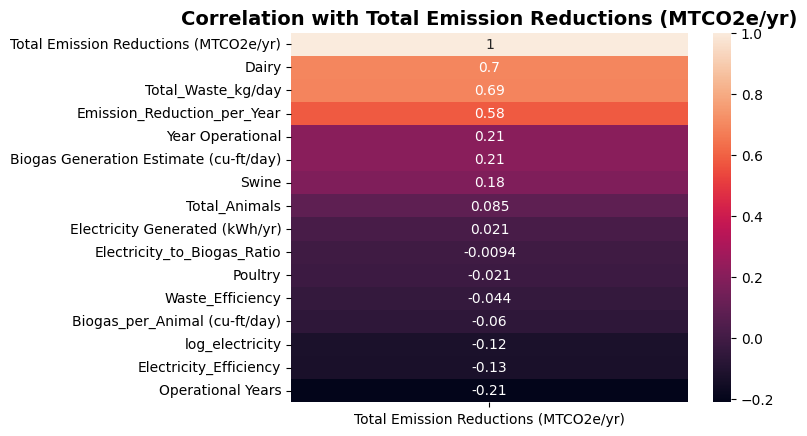

In [27]:
# Correlation chart

corr = dataset.corr(numeric_only=True)

sns.heatmap(corr[[Predict]].sort_values(by=Predict, ascending=False),
            annot=True, cmap="rocket")

plt.title(f"Correlation with {Predict}", fontsize=14, fontweight="bold")
plt.show()

In [28]:
print("Median:", dataset[Predict].median())    #Helps to choose a threshold for the Classification Report

Median: 24094.42858


In [29]:
# Creating a Classification Report, Applying Classification Model

from sklearn.metrics import classification_report                                                 # Shows how accurate the model is

dataset["CO2_Categories"] = np.where(dataset[Predict] >= 24100, "High", "Low")

X_Classifier = dataset.drop(columns=[Predict, "CO2_Categories"])
X_Classifier = X_Classifier.select_dtypes(include=[np.number])  # Extracting only numeric values
Y_Classifier = dataset["CO2_Categories"]

X_train_Classification, X_test_Classification, Y_train_Classification, Y_test_Classification = train_test_split(X_Classifier, Y_Classifier, test_size=0.2, random_state=42)


from sklearn.ensemble import RandomForestClassifier


Classification = RandomForestClassifier(random_state=42)
Classification.fit(X_train_Classification, Y_train_Classification)
Y_pred_Classifier = Classification.predict(X_test_Classification)

print("Classification Report:")
print (classification_report(Y_test_Classification, Y_pred_Classifier))


Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.93      0.94        56
         Low       0.91      0.93      0.92        43

    accuracy                           0.93        99
   macro avg       0.93      0.93      0.93        99
weighted avg       0.93      0.93      0.93        99



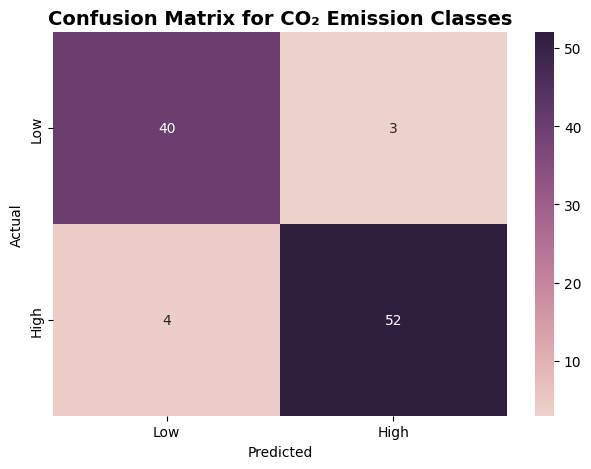

In [30]:
# Plotting a Confusion Matrix
                                                       # Counts all the accurate and inaccurate predictions by the model
from sklearn.metrics import confusion_matrix

Lables = ["Low", "High"]
CM = confusion_matrix(Y_test_Classification, Y_pred_Classifier, labels=Lables)

p_palette= sns.cubehelix_palette(as_cmap=True)

sns.heatmap(CM, annot=True, fmt="d", cmap=p_palette, xticklabels=Lables, yticklabels=Lables)
plt.title("Confusion Matrix for CO₂ Emission Classes", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## **BIOGAS GENERATION**

In [31]:
Predict2 = "Biogas Generation Estimate (cu-ft/day)"


X = dataset.drop(columns=[Cols for Cols in New_Dataset if Cols in dataset.columns] + [Predict2], errors="ignore")   # "Biogas Generation" stored in "Y" and all the other features are stored in "X".
Y = dataset[Predict2]

In [32]:
for new_cols in X.select_dtypes(include=["object"]).columns.tolist():
    le = LabelEncoder()
    X[new_cols] = le.fit_transform(X[new_cols].astype(str))

In [33]:
    #K-Fold
from sklearn.model_selection import KFold

KF = KFold(n_splits=5, shuffle=True, random_state=42)

MAE_Scores = []
R2_Scores = []


for fold_x, (train_index, test_index) in enumerate(KF.split(X), start= 1):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  Y_train, Y_test = Y[train_index], Y[test_index]

In [34]:
  Model2 = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)

  Model2.fit(X_train, Y_train)
  Y_pred = Model2.predict(X_test)

  R2_Scores.append(r2_score(Y_test, Y_pred))
  MAE_Scores.append(mean_absolute_error(Y_test, Y_pred))
  print(f"Fold{fold_x}:R2={R2_Scores[-1]:.3f}, MAE={MAE_Scores[-1]:.3f}")

  print()

print(f"Cross Validation R2 Score: {np.mean(R2_Scores):.3f} ± {np.std(R2_Scores):.3f}")
print(f"Cross Validation MAE Score: {np.mean(MAE_Scores):.3f} ± {np.std(MAE_Scores):.3f}")

Fold5:R2=0.796, MAE=70151.711

Cross Validation R2 Score: 0.796 ± 0.000
Cross Validation MAE Score: 70151.711 ± 0.000


In [35]:
# Model Training

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

XGmodelx = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
XGmodelx.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [36]:
# Final Prediction
Y_pred_final = XGmodelx.predict(X_test)

Outcome_r2 = r2_score(Y_test, Y_pred_final)
Outcome_mae = mean_absolute_error(Y_test, Y_pred_final)

print("\nFinal Evaluations:")
print(f"R2:  {Outcome_r2:.3f}")
print(f"MAE: {Outcome_mae:.3f}")


Final Evaluations:
R2:  0.750
MAE: 102505.547


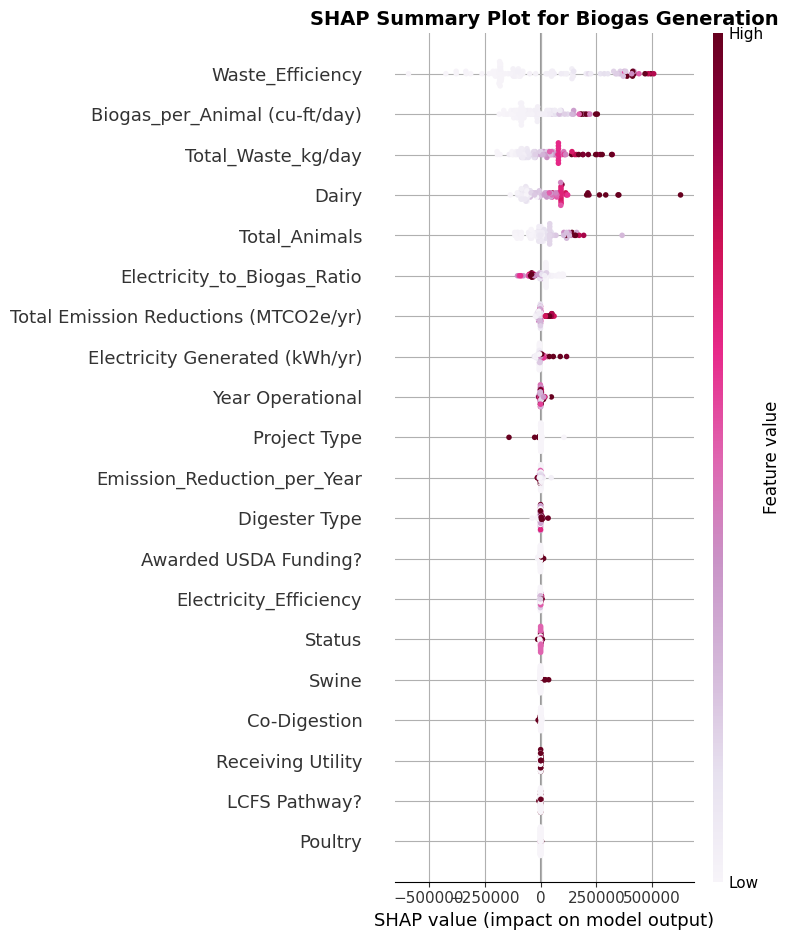

In [37]:
#Plotting SHAP Plot

                                                                        # Depicts how much each feature contributed to the model's predictions
Explainer = shap.Explainer(XGmodelx, X_train)
Shap_Values = Explainer(X_test)

cmap = plt.cm.PuRd
Colors = [cmap(i) for i in range(cmap.N)]

plt.figure(figsize=(10,6))
shap.summary_plot(Shap_Values, X_test, plot_type="dot", cmap="PuRd", show=False)

plt.grid(True)

plt.title("SHAP Summary Plot for Biogas Generation", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

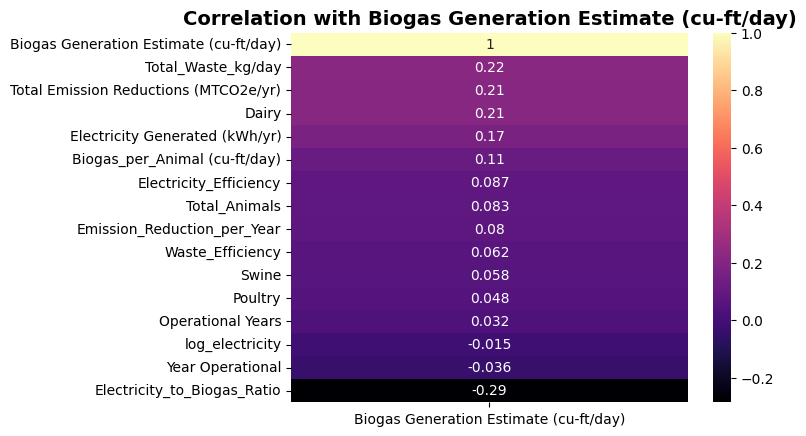

In [38]:
# Correlation chart

corr = dataset.corr(numeric_only=True)

sns.heatmap(corr[[Predict2]].sort_values(by=Predict2, ascending=False),
            annot=True, cmap="magma")

plt.title(f"Correlation with {Predict2}", fontsize=14, fontweight="bold")
plt.show()

In [39]:
print("Median:", dataset[Predict2].median())    #Helps to choose a threshold for the Classification Report

Median: 344690.0


In [40]:
# Creating a Classification Report & Applying Classification Model

from sklearn.metrics import classification_report

dataset["Biogas_Categories"] = np.where(dataset[Predict2] >= 345000, "High", "Low")

Xx_Classifier = dataset.drop(columns=[Predict2, "Biogas_Categories"])
Xx_Classifier = Xx_Classifier.select_dtypes(include=[np.number])
Yy_Classifier = dataset["Biogas_Categories"]

Xx_train_Classification, Xx_test_Classification, Yy_train_Classification, Yy_test_Classification = train_test_split(Xx_Classifier, Yy_Classifier, test_size=0.2, random_state=42)

In [41]:
# Encoding

Encoder = LabelEncoder()
Yy_train_Classification = Encoder.fit_transform(Yy_train_Classification)
Yy_test_Classification = Encoder.transform(Yy_test_Classification)

from xgboost import XGBClassifier

Classification_x = XGBClassifier(random_state=42)
Classification_x.fit(Xx_train_Classification, Yy_train_Classification)
Yy_pred_Classifier = Classification_x.predict(Xx_test_Classification)

print("Classification Report:")
print (classification_report(Yy_test_Classification, Yy_pred_Classifier))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        50
           1       0.96      0.98      0.97        49

    accuracy                           0.97        99
   macro avg       0.97      0.97      0.97        99
weighted avg       0.97      0.97      0.97        99



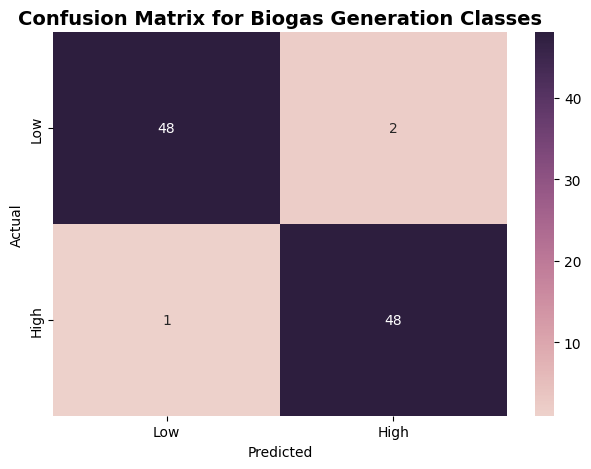

In [42]:
# Plotting a Confusion Matrix
                                                       # Counts all the accurate and inaccurate predictions by the model
from sklearn.metrics import confusion_matrix

labels = np.unique(Yy_test_Classification)

cm = confusion_matrix(Yy_test_Classification, Yy_pred_Classifier, labels=labels)

p_palette= sns.cubehelix_palette(as_cmap=True)

sns.heatmap(cm, annot=True, fmt="d", cmap=p_palette, xticklabels=Lables, yticklabels=Lables)
plt.title("Confusion Matrix for Biogas Generation Classes", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# **GEOGRAPHICAL ANALYSIS**

In [43]:


Abb_States = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA',
    'Michigan':'MI','Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM',
    'New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT',
    'Virginia':'VA','Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

Loca_dataset["State_Abbreviations"] = Loca_dataset["State"].map(Abb_States)

Numbering = Loca_dataset["State_Abbreviations"].value_counts().reset_index()
Numbering.columns = ["State", "Digesters"]

fig = px.choropleth(Numbering, locations="State", locationmode="USA-states", color="Digesters", scope="usa", color_continuous_scale="Blues", title="State-Level Adoption of Digesters"
)

fig.show()


In [44]:
Loca_dataset

,Project Name,Project Type,City,Latitude,Longitude,County,State,Digester Type,Status,Year Operational,...,Total_Animals,Biogas_per_Animal (cu-ft/day),Emission_Reduction_per_Year,Electricity_to_Biogas_Ratio,Total_Waste_kg/day,Waste_Efficiency,Electricity_Efficiency,States,Regions,State_Abbreviations
0,Sheland Farms Digester,Farm Scale,Adams,43.8616,-76.0001,Jefferson,New York,Complete Mix,Operational,2007,...,625,57.600000,112.420717,10.590000,21250,1.694118,17.940706,New York,Northeast,NY
1,Roeslein Alternative Energy - Ruckman Farm Dig...,Farm Scale,Albany,42.6518,-73.7545,Gentry,Missouri,Covered Lagoon,Operational,2016,...,28800,3.793750,4629.287059,9.211422,144000,0.758750,6.989167,Missouri,Midwest,MO
2,"Heller Farms / Cow Poo, LLC Digester",Farm Scale,Alma Center,44.4372,-90.9113,Jackson,Wisconsin,Complete Mix,Operational,2012,...,3900,171.765436,594.877614,4.926217,74600,8.979694,44.235925,Wisconsin,Midwest,WI
3,Diamond K Dairy/Ponderosa Dairies Digester,Multiple Farm/Facility,Altura,37.1814,-7.5031,Winona,Minnesota,Complete Mix,Shut down,2013,...,1070,136.850467,1865.930046,0.408598,36380,4.025014,1.644612,Minnesota,Midwest,MN
4,"Amana Farms, Inc. Digester",Farm Scale,Amana,41.8025,-91.8782,Iowa,Iowa,Mixed Plug Flow,Operational,2008,...,1250,1478.960000,1166.812596,12.320009,25000,73.948000,911.040000,Iowa,Midwest,IA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,Lakeshore Dairy Digester: Brightmark RNG,Farm Scale,Wilson,35.7258,-77.9111,Niagra,New York,Complete Mix,Construction,2021,...,1900,300.623053,8812.841472,2.054104,64600,8.841854,18.162090,New York,Northeast,NY
487,Lakeshore Dairy Digester,Farm Scale,Wilson,35.7258,-77.9111,Niagra,New York,Complete Mix,Operational,2017,...,1900,300.623053,3083.270458,2.054104,64600,8.841854,18.162090,New York,Northeast,NY
488,Wolf Creek Dairy Digester,Farm Scale,Windsor,42.3141,-83.0368,Weld,Colorado,Mixed Plug Flow,Construction,2023,...,7100,11.970563,0.000000,97.645692,241400,0.352075,34.378645,Colorado,West,CO
489,Tinedale Farms Digester,Farm Scale,Wrightstown,40.0363,74.6178,Jackson,Wisconsin,Fixed Film/Attached Media,Shut down,1999,...,1800,111.111111,1923.477295,27.922500,61200,3.267974,91.250000,Wisconsin,Midwest,WI


In [45]:
Target = "Electricity Generated (kWh/yr)"

Result= "Emission_Reduction_Highest_Performance_Digesters_map.html"


MAPS_Data = pd.read_csv("Location.csv")

MAPS_Data.columns = MAPS_Data.columns.str.strip()

In [46]:

for col in ["Latitude", "Longitude", Target]:
    MAPS_Data[col] = pd.to_numeric(MAPS_Data[col], errors="coerce")

MAPS_Data = MAPS_Data.dropna(subset=["Latitude", "Longitude", Target]).copy()
MAPS_Data = MAPS_Data[
    (MAPS_Data["Latitude"].between(-90, 90)) &
    (MAPS_Data["Longitude"].between(-180, 180)) &
    (MAPS_Data["Latitude"] != 0) &
    (MAPS_Data["Longitude"] != 0)
].copy()

In [47]:
q75 = MAPS_Data[Target].quantile(0.75)   # Top quartile threshold
High_Performance= MAPS_Data[MAPS_Data[Target] >= q75].copy()

In [48]:
import branca.colormap as bcm

In [49]:
vmin = float(High_Performance[Target].min())
vmax = float(High_Performance[Target].max())

if vmax == vmin:
    vmax = vmin + 1e-9


In [50]:

center_lat = float(MAPS_Data["Latitude"].median())
center_lng = float(MAPS_Data["Longitude"].median())
m = folium.Map(location=[center_lat, center_lng], zoom_start=5, tiles="cartodbpositron")


In [51]:
def _norm(val, lo=vmin, hi=vmax):
    rng = hi - lo
    if rng <= 0:
        return 1.0
    return max(0.0, min(1.0, (val - lo) / rng))

heat_data = [
    [float(r["Latitude"]), float(r["Longitude"]), _norm(float(r[Target]))]
    for _, r in High_Performance.iterrows()
]

HeatMap(heat_data, radius=18, blur=22, min_opacity=0.3, max_zoom=10, name="HeatMap").add_to(m)

In [52]:
cluster = MarkerCluster(name="High Performer Markers").add_to(m)

for _, r in High_Performance.iterrows():
    lat, lng = float(r["Latitude"]), float(r["Longitude"])
    val = float(r[Target])
    color = cmap(val)
    popup_html = folium.Popup(
        html=(
            f"<b>Project:</b> {r.get('Project Name','N/A')}<br>"
            f"<b>State:</b> {r.get('State','N/A')}<br>"
            f"<b>Digester Type:</b> {r.get('Digester Type','N/A')}<br>"
            f"<b>{Target}:</b> {val:,.0f}"
        ),
        max_width=320
    )
    folium.CircleMarker(
        location=[lat, lng],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.9,
        weight=1,
        popup=popup_html
    ).add_to(cluster)

In [53]:
import branca.colormap as bcm

cmap = bcm.linear.Purples_09.scale(vmin, vmax)

cmap.add_to(m)
folium.LayerControl().add_to(m)

In [54]:
m.save(Result)
print(f"Saved: {Result}")
print(f"Records used: total={len(MAPS_Data):,}, High Performers={len(High_Performance):,}")

Saved: Emission_Reduction_Highest_Performance_Digesters_map.html
Records used: total=490, High Performers=123
